# Generative Audio Lab: Diffusion vs Autoregressive Models

*Assoc. Prof. Dorien Herremans*

This lab demonstrates conceptual and perceptual differences between diffusion-based and autoregressive text-to-music generation.

We explore:
- Diffusion inference steps
- Guidance scale (classifier-free guidance)
- Spectrogram analysis
- Autoregressive temperature
- Mechanistic comparison

⚠ Designed to run safely on Colab T4 GPU.

# Setup


**Important:**

You can run this as your own copy though: 'File - Open in Playground mode'

In Colab, enable GPU first:
Runtime → Change runtime type → GPU

In [1]:
!pip install -q torchaudio librosa matplotlib
!pip uninstall -y diffusers transformers accelerate
!pip install diffusers==0.30.3 transformers==4.44.2 accelerate==0.33.0

Found existing installation: diffusers 0.30.3
Uninstalling diffusers-0.30.3:
  Successfully uninstalled diffusers-0.30.3
Found existing installation: transformers 4.44.2
Uninstalling transformers-4.44.2:
  Successfully uninstalled transformers-4.44.2
Found existing installation: accelerate 0.33.0
Uninstalling accelerate-0.33.0:
  Successfully uninstalled accelerate-0.33.0
  Using cached diffusers-0.30.3-py3-none-any.whl.metadata (18 kB)
  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
  Using cached accelerate-0.33.0-py3-none-any.whl.metadata (18 kB)
Using cached diffusers-0.30.3-py3-none-any.whl (2.7 MB)
Using cached transformers-4.44.2-py3-none-any.whl (9.5 MB)
Using cached accelerate-0.33.0-py3-none-any.whl (315 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [transformers] [transformers]


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from IPython.display import Audio, display
import gc

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

Using device: mps


# Load Diffusion Model (AudioLDM2-Music)
Smaller variant for stable T4 execution.

In [5]:
from diffusers import AudioLDM2Pipeline

pipe_diff = AudioLDM2Pipeline.from_pretrained(
    # 'cvssp/audioldm2-music-665k',
    'cvssp/audioldm2-music',
    torch_dtype=torch.float16
)
pipe_diff = pipe_diff.to(device)

/Users/dorien_herremans/Dropbox/DoBrain/AC/Courses/MGAI/labs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading pipeline components...: 100%|██████████| 11/11 [00:03<00:00,  2.88it/s]


# Load Autoregressive Model (MusicGen Small)

In [6]:
from transformers import MusicgenForConditionalGeneration, AutoProcessor

processor = AutoProcessor.from_pretrained('facebook/musicgen-small')
model_ar = MusicgenForConditionalGeneration.from_pretrained('facebook/musicgen-small').to(device)

/Users/dorien_herremans/Dropbox/DoBrain/AC/Courses/MGAI/labs/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/Users/dorien_herremans/Dropbox/DoBrain/AC/Courses/MGAI/labs/.venv/lib/python3.12/site-packages/transformers/models/encodec/modeling_encodec.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.register_buffer("padding_total", torch.tensor(kernel_size - stride, dtype=torch.int64), persistent=False)


# Prompt

In [7]:
# prompt = 'uplifting EDM song'
prompt = 'Techno music with a strong, upbeat tempo and high melodic riffs'

# Part 1 - Diffusion: Inference Steps
We vary the number of denoising iterations.

In [8]:
steps_list = [2, 5, 200]

for steps in steps_list:
    print(f"\nGenerating with {steps} steps...")

    out = pipe_diff(
        prompt=prompt,
        num_inference_steps=steps,
        guidance_scale=3.0,
        audio_length_in_s=5.0,           # ← controls output length (default may be very short!)
        negative_prompt="low quality, noisy, repetitive",   # optional
        generator=torch.Generator(device).manual_seed(42),  # for reproducibility
    )

    print(type(out))
    print(dir(out))           # see available attributes
    print(out)

    # The modern / correct way
    audio = out.audios[0]               # almost always works

    print(f"Inference steps: {steps} | audio type: {type(audio)} | shape: {audio.shape}")

    display(Audio(audio, rate=16000))

    # Very important with float16 + long generations
    if device.type == "cuda":
        torch.cuda.empty_cache()

    elif device.type == "mps":
        torch.mps.empty_cache()
    gc.collect()


Generating with 2 steps...


100%|██████████| 2/2 [00:04<00:00,  2.35s/it]


<class 'diffusers.pipelines.pipeline_utils.AudioPipelineOutput'>
['__annotations__', '__class__', '__class_getitem__', '__contains__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__or__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'audios', 'clear', 'copy', 'fromkeys', 'get', 'items', 'keys', 'move_to_end', 'pop', 'popitem', 'setdefault', 'to_tuple', 'update', 'values']
AudioPipelineOutput(audios=array([[ 0.05349731,  0.04620361,  0.04367065, ..., -0.11248779,
         0.00405502,  0.03283691]], dtype=float32))
Inference steps: 2 | audio type: <class 'numpy.n


Generating with 5 steps...


100%|██████████| 5/5 [00:00<00:00,  6.68it/s]


<class 'diffusers.pipelines.pipeline_utils.AudioPipelineOutput'>
['__annotations__', '__class__', '__class_getitem__', '__contains__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__or__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'audios', 'clear', 'copy', 'fromkeys', 'get', 'items', 'keys', 'move_to_end', 'pop', 'popitem', 'setdefault', 'to_tuple', 'update', 'values']
AudioPipelineOutput(audios=array([[ 0.0239563 ,  0.01465607, -0.00984955, ..., -0.05386353,
         0.06634521, -0.02664185]], dtype=float32))
Inference steps: 5 | audio type: <class 'numpy.n


Generating with 200 steps...


100%|██████████| 200/200 [00:31<00:00,  6.31it/s]


<class 'diffusers.pipelines.pipeline_utils.AudioPipelineOutput'>
['__annotations__', '__class__', '__class_getitem__', '__contains__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__ior__', '__iter__', '__le__', '__len__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__or__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__reversed__', '__ror__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', 'audios', 'clear', 'copy', 'fromkeys', 'get', 'items', 'keys', 'move_to_end', 'pop', 'popitem', 'setdefault', 'to_tuple', 'update', 'values']
AudioPipelineOutput(audios=array([[ 0.04266357,  0.03244019,  0.01087189, ..., -0.05050659,
         0.33935547,  0.02798462]], dtype=float32))
Inference steps: 200 | audio type: <class 'numpy

## Discussion Questions (Diffusion Steps)
- Does increasing steps reduce background noise or hiss?
- Does rhythm become more stable?
- Where do improvements saturate?
- Why would diffusion need multiple iterative refinements?

# Part 2 - Diffusion: Guidance Scale

In [9]:
guidance_values = [0.5, 1.0, 3.0, 6.0]

for g in guidance_values:
    audio = pipe_diff(
        prompt=prompt,
        num_inference_steps=50,
        guidance_scale=g,
        audio_length_in_s=4,
        negative_prompt="low quality, noisy, repetitive",   # optional
        generator=torch.Generator(device).manual_seed(42),  # for reproducibility
    ).audios[0]

    print(f'Guidance scale: {g}')
    display(Audio(audio, rate=16000))
    if device.type == "cuda":
        torch.cuda.empty_cache()

    elif device.type == "mps":
        torch.mps.empty_cache()

100%|██████████| 50/50 [00:11<00:00,  4.47it/s]


Guidance scale: 0.5


100%|██████████| 50/50 [00:08<00:00,  6.24it/s]


Guidance scale: 1.0


100%|██████████| 50/50 [00:10<00:00,  4.94it/s]


Guidance scale: 3.0


100%|██████████| 50/50 [00:07<00:00,  7.07it/s]


Guidance scale: 6.0


## Discussion Questions (Guidance)
- Does low guidance produce more generic textures?
- Does high guidance increase repetition?
- Does semantic clarity improve linearly?
- Why can strong guidance reduce diversity?

# Part 3 - Spectrogram Analysis

In [10]:
def plot_spectrogram(audio, sr=16000, title=''):
    S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)

    plt.figure(figsize=(8,4))
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

100%|██████████| 100/100 [00:12<00:00,  7.89it/s]


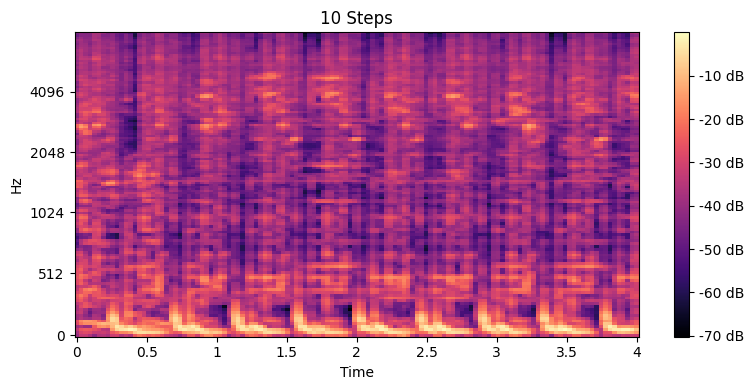

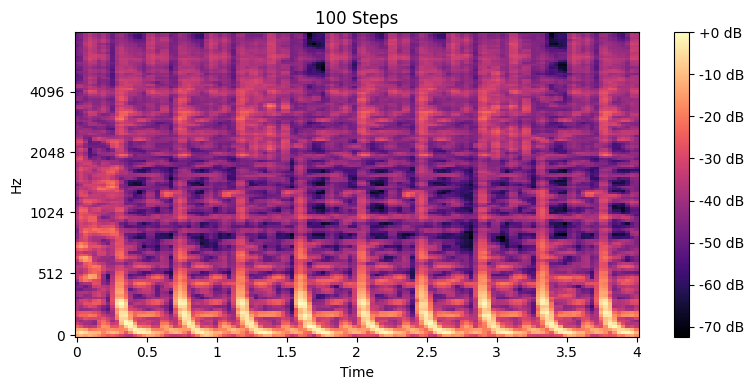

In [11]:
audio_low = pipe_diff(prompt=prompt, num_inference_steps=10, guidance_scale=3.0, audio_length_in_s=4).audios[0]
audio_high = pipe_diff(prompt=prompt, num_inference_steps=100, guidance_scale=3.0, audio_length_in_s=4).audios[0]

plot_spectrogram(audio_low, title='10 Steps')
plot_spectrogram(audio_high, title='100 Steps')
if device.type == "cuda":
    torch.cuda.empty_cache()

elif device.type == "mps":
    torch.mps.empty_cache()

## Spectrogram Discussion
- Is high-frequency noise reduced with more steps?
- Do harmonic bands appear sharper?
- Is temporal smearing reduced?
- Why would iterative denoising clean high frequencies first or last?

# Part 4 - Autoregressive Generation (MusicGen)

In [13]:
inputs = processor(text=[prompt], return_tensors='pt').to(device)

for temp in [0.7, 1.0, 1.5]:
    audio_values = model_ar.generate(
        **inputs,
        do_sample=True,
        temperature=temp,
        max_new_tokens=512
    )

    audio = audio_values[0].cpu().numpy()
    print(f'Temperature: {temp}')
    display(Audio(audio, rate=32000))

    if device.type == "cuda":
        torch.cuda.empty_cache()

    elif device.type == "mps":
        torch.mps.empty_cache()


Temperature: 0.7


Temperature: 1.0


Temperature: 1.5


## Discussion Questions (Autoregressive)
- Does higher temperature increase randomness?
- Does structure feel more sequential than diffusion?
- Is long-term rhythm more stable?
- Why might AR models produce stronger global structure?


## Final Reflection Questions
- Why does diffusion refine globally while AR builds sequentially?
- Which model would scale better to 30 seconds? Why?
- Which model is easier to control stylistically?
- How do architectural differences explain perceptual differences?

# Answer key


## Diffusion – Inference Steps

**Q: What changes when increasing inference steps?**

**Expected observations:**
- Low steps (e.g., 10): noisy artifacts, less structure, blurred timbre
- Medium steps (20): clearer structure, improved coherence
- Higher steps (40): more refined texture and stability

**Conceptual explanation:**
- Diffusion models iteratively denoise.
- More steps = better approximation of the reverse diffusion process.
- Each step reduces residual noise and improves structure.
- Diminishing returns appear beyond a certain point.

**Important insight:**  
Unlike images, audio artifacts manifest as:
- Hiss
- Metallic ringing
- Temporal instability

---

## Diffusion – Guidance Scale

**Q: What happens when guidance scale increases?**

**Expected observations:**
- Low guidance (1–2): more diverse, sometimes loosely related to prompt
- Medium guidance (4–5): balanced prompt adherence and naturalness
- High guidance (7–8+): stronger prompt match, but sometimes unnatural or distorted

**Conceptual explanation:**  
Guidance scale controls how strongly the model follows the conditional prompt versus the unconditional prior.

- Higher scale pushes output toward the prompt embedding
- Reduces diversity
- Can amplify artifacts

**Key tradeoff:**  
- Low guidance → creativity  
- High guidance → control  
- Too high → instability

---

## Diffusion – Why Do Artifacts Increase at High Guidance?

Because the model over-amplifies differences between:
- conditional prediction
- unconditional prediction

This can:
- distort harmonics
- produce unnatural transients
- increase high-frequency noise

---

## Autoregressive – MusicGen

**Q: How does autoregressive generation differ perceptually?**

**Expected observations:**
- Strong rhythmic consistency
- Clear musical tokens and structure
- Sometimes repetitive patterns

**Conceptual explanation:**  
Autoregressive models predict one token at a time, conditioning strictly on previous tokens.  

**Advantages:**
- Strong temporal coherence
- Stable rhythm

**Disadvantages:**
- Exposure bias
- Error accumulation
- Looping/repetition


- MusicGen is mostly a transformer-based model:
  - It predicts audio in chunks conditioned on previous chunks.
  -	Because of this, structure tends to feel sequential — verses, chords, patterns progress in order.
  -	Compared with diffusion models (like AudioLDM2), which are denoising an entire latent representation:
    -	Diffusion sometimes produces “floating textures” without a strong global structure.
    -	Transformers tend to keep long-term musical dependencies better.
- MusicGen generally keeps long-term rhythm more stable than diffusion models.
- Temperature:
  - Higher temperature → more randomness in note choices, timbre, and phrasing.
	- Lower temperature → more conservative output, closer to the most probable continuation

---

## Diffusion vs Autoregressive – Structural Differences

| Property | Diffusion | Autoregressive |
|----------|-----------|----------------|
| Generation | Global denoising process | Sequential token prediction |
| Temporal structure | Flexible | Strong causality |
| Coherence | Improves iteratively | Maintains sequence strictly |
| Sampling speed | Slower | Faster per token |
| Diversity vs control | High diversity, lower prompt adherence | Lower diversity, stronger structure |

**Key conceptual difference:**  
Diffusion refines a noisy whole; autoregressive builds incrementally. This affects long-range coherence, error accumulation, and controllability.

---

## Spectrogram Observations

**Q: What changes when steps increase?**

- Reduced broadband noise
- Clearer harmonic stacks
- More defined transients
- Cleaner high-frequency structure

**Low-step diffusion often shows:**  
- Speckled high-frequency noise  
- Blurred harmonic bands

**High guidance sometimes shows:**  
- Overly sharp or artificial harmonics  
- Harsh high-frequency energy

---



## Why Audio Diffusion Is Harder Than Image Diffusion

- Audio requires strict temporal continuity
- Phase coherence matters
- Human hearing is sensitive to waveform artifacts
- Small errors are very perceptible compared to images

---

## Why Might Diffusion Be Preferred for Creative Audio?

- Models global structure implicitly  
- Captures complex timbral distributions  
- Allows fine control via conditioning  

Autoregressive models are strong for symbolic or structured music, but less flexible for rich sound design.

